# **ChromBPNet Downstream Analysis**

## <div style = 'background-color:skyblue'> <center> Section 1: Data Processing</div>

### PWM to Consensus Sequence 

This takes the JASPAR_2026 motif file and generates a .tsv file that has two columns:
   
   1. MA_id
   2. Sequence (e.g., ATTGCATGATACCT)

In [ ]:
# Libraries
import os
import pandas as pd

In [ ]:
# Paths
jaspar_2026="/scratch/prj/stem_cells_pituitary/Georgia/genome/JASPAR_CORE_2026_non-redundant.meme"
output_tsv="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences.tsv"
nucleotides = ['A', 'C', 'G', 'T']

os.path.exists(jaspar_2026)

In [ ]:
# Function for generating .tsv file with no thresholds on sequence

print("Begin parsing MEME file.")

with open(jaspar_2026, "r") as infile, open(output_tsv, "w") as outfile:
    current_id = None
    matrix_lines = []
    is_reading_matrix = False

    for line in infile:
        line = line.strip()
        
        # Identify the start of a motif
        if line.startswith("MOTIF"):
            # End sequence of previous motif
            if current_id and matrix_lines:
                consensus = ""
                for row in matrix_lines:
                    probs = [float(x) for x in row.split()]
                    max_idx = probs.index(max(probs))
                    consensus += nucleotides[max_idx]
                outfile.write(f"{current_id}\t{consensus}\n")
            
            # Begin sequence of new motif
            parts = line.split()
            current_id = parts[1]
            matrix_lines = []
            is_reading_matrix = False
            
        # Identify the letter-probability matrix within the motif information
        elif line.startswith("letter-probability matrix"):
            is_reading_matrix = True
            continue
            
        # Extract the letter-probability matrix
        elif is_reading_matrix:
            if not line or line.startswith("URL"):
                is_reading_matrix = False
                continue
            matrix_lines.append(line)

    # Last motif in the file
    if current_id and matrix_lines:
        consensus = ""
        for row in matrix_lines:
            probs = [float(x) for x in row.split()]
            max_idx = probs.index(max(probs))
            consensus += nucleotides[max_idx]
        outfile.write(f"{current_id}\t{consensus}\n")

print(f"Successfully created {output_tsv}")

In [ ]:
# Check
!head -n 5 /scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences.tsv
!grep "MA0784.2" /scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences.tsv
!grep "MA0112.3" /scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences.tsv

### Motif Sequence Files - Grouping Lineage Markers

In the CPA paper -> there are distinct grouping lineage markers (TFs) that can be associated with different cell fates. 

The following:

1. Takes the TF names from each group
2. Uses an MA_id:Name dictionary to align each TF with an MA_id
3. Generates a .tsv file in the same format as the motif_sequences.tsv file 

These files are needed as input for the Marginal Footprinting command to run properly. 

In [ ]:
# Generate dictionary of TFs to MA ID

jaspar_2026="/scratch/prj/stem_cells_pituitary/Georgia/genome/JASPAR_CORE_2026_non-redundant.meme"

# Create a disctionary with key = ID and value = motif name
id_to_motif = {}

# Extract these names from the jaspar file
with open(jaspar_2026, 'r') as file:
    for line in file:
        if line.startswith("MOTIF"):
            parts = line.split()
            # parts[0] is the word MOTIF
            # parts[1] is the ID
            # parts[2] is the Motif name
            if len(parts) >= 3:
                id_to_motif[parts[1]] = parts[2]

print(f'Loaded {len(id_to_motif)} motif names for mapping')

In [ ]:
# Check file 
print(dict(list(id_to_motif.items())[:5]))

In [ ]:
# List of target TFs

#grouping_1_down = ["Bhlha15", "Mitf", "Npas4", "Onecut2", "Pbx3", "Rorb", "Scrt1", "Zeb1"]

grouping_1_up = ["Ebf1", "Elf3", "Grhl2", "Hic2", "Hnf4g", "Irf1", "Irf9", "Klf10", "Klf11", 
                 "Klf2", "Klf3", "Klf4", "Klf5", "Klf6", "Nfia", "Nfib", "Nfix", "Nfkb1", "Prop1", 
                 "Rela", "Relb", "Rest", "Rfx4", "Runx1", "Six1", "Six2", "Six4", "Sox2", "Sox4", 
                 "Sox6", "Sox8", "Sox9", "Stat1", "Stat6", "Tcf7l2", "Tead2", "Tead3", "Tead4"]

#grouping_2_down = ["Etv1", "Hlf", "Klf5", "Rorc"]

grouping_2_up = ["Foxl2", "Foxo6", "Nhlh2", "Nr5a1"]

grouping_4_down = ["Bcl11b", "Cebpd", "Dbp", "Dmrta2", "Ebf1", "Esrrg", "Foxl2", "Hif1a", "Irf1", 
                   "Klf9", "Myb", "Neurod1", "Nfil3", "Npas4", "Nr3c1", "Nr3c2", "Pitx1", "Pknox2", 
                   "Pou6f2", "Runx2", "Rxra", "Smad3", "Tbx19", "Tcf7l2", "Tef", "Tfeb", "Tgif1", 
                   "Trps1", "Twist2"]

grouping_4_up = ["Ascl1", "Bhlha15", "Elf3", "Etv1", "Foxp2", "Hnf4g", "Jdp2", "Maf", "Mef2c", 
                 "Meox1", "Msx1", "Nfatc1", "Nfatc2", "Nfia", "Nfib", "Nfix", "Nr2f2", "Pax6", 
                 "Pax7", "Pbx3", "Pknox1", "Plagl1", "Prdm9", "Prrx1", "Sox11", "Sox13", "Sox2", 
                 "Sox4", "Sox5", "Sox9", "Srebf2", "Stat6", "Tbx15", "Tfap4", "Vax1"]

#grouping_6_down = ["Gata2", "Gli2", "Grhl1", "Hlf", "Lef1", "Nr3c1", "Nr3c2", "Rxrg", "Srebf2", 
#                   "Stat2", "Tcf7l2"]

grouping_6_up = ["Ascl1", "Creb3l1", "Esr1", "Jdp2", "Lhx3", "Msx1", "Nfia", "Nfix", "Pitx2", 
                 "Pou1f1", "Pou2f2", "Pou6f2"]

#grouping_7_down = ["Arid3b", "Ascl1", "Lhx3", "Mef2c", "Pitx1", "Pitx2"]

grouping_7_up = ["Atf3", "Bach2", "Cebpb", "Cebpd", "Egr1", "Egr2", "Elf3", "Foxo1", "Foxp1", "Gli2",
                 "Glis3", "Irf1", "Klf9", "Mlxipl", "Nfatc2", "Nr3c1", "Nr3c2", "Plagl1", "Rarb", "Rfx4", 
                 "Sox2", "Sox6", "Stat3", "Stat4", "Tfeb"]

#grouping_8_down = ["Bach1", "Bhlha15", "Bnc2", "Cebpb", "Creb3l1", "Creb5", "Ebf1", "Ehf", "Fos", "Fosl2", 
#                   "Glis3", "Hsf4", "Jun", "Junb", "Jund", "Klf11", "Klf4", "Mafb", "Meis2", "Mxi1", 
#                   "Myb", "Myc", "Mycn", "Nfix", "Nfkb2", "Pknox1", "Plagl1", "Sox6", "Stat5b", "Tfap4", 
#                   "Tfcp2l1", "Tgif2", "Zbtb12"]

grouping_8_up = ["Dbp", "Foxl2", "Foxp2", "Gata2", "Hlf", "Isl1", "Lef1", "Nr5a1", "Pitx1", "Rorb", "Shox2"]

In [ ]:
# Paths
motif_sequences = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences.tsv"
motif_sequences_subset = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_subset.tsv"

grouping_1_up_sub = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_g1_up.tsv"
grouping_2_up_sub = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_g2_up.tsv"
grouping_4_up_sub = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_g4_up.tsv"
grouping_4_down_sub = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_g4_down.tsv"
grouping_6_up_sub = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_g6_up.tsv"
grouping_7_up_sub = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_g7_up.tsv"
grouping_8_up_sub = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_g8_up.tsv"

In [ ]:
# Align TFs with their associated MA IDs from the JASPAR file

target_tfs_upper = {tf.upper() for tf in grouping_4_down}

target_ids = []
found_in_jaspar = set()

for ma_id, name in id_to_motif.items():
    if name.upper() in target_tfs_upper:
        target_ids.append(ma_id)
        found_in_jaspar.add(name.upper())

missing_tfs = [tf for tf in grouping_4_down if tf.upper() not in found_in_jaspar]

print(f"Total Target TFs: {len(grouping_4_down)}")
print(f"TFs found in JASPAR: {len(found_in_jaspar)}")
print(f"Total MA IDs mapped: {len(target_ids)}")
print(f"TFs NOT found: {len(missing_tfs)}")

In [ ]:
# Check the TFs were correctly aligned
mapping_data = []
for ma_id in target_ids:
    mapping_data.append({
        "MA_ID": ma_id,
        "TF_Name": id_to_motif[ma_id]
    })
    
df_mapping = pd.DataFrame(mapping_data).sort_values("TF_Name")

print(df_mapping.head(5))

In [ ]:
# Generate the subset file
target_ids_set = set(target_ids)
count = 0

with open(motif_sequences, 'r') as infile, open(grouping_4_down_sub, 'w') as outfile:
    for line in infile:
        parts = line.strip().split('\t')
        if parts and parts[0] in target_ids_set:
            outfile.write(line)
            count += 1

print(f"TF Motif Sequences in file: {count}")

In [ ]:
# Check file
! head -n 5 /scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_subset.tsv

In [ ]:
# Split into files of size 50 to run faster
#! split -l 50 -d --additional-suffix=.tsv /scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences_subset.tsv motif_subset_part_

### Marginal Footprinting - Merge Output .h5 files

In [ ]:
# Load libraries
import h5py
import hdf5plugin
import os
from pathlib import Path
import glob
import sys

In [ ]:
files_list = glob.glob('/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Thyrotrophs/marginal_footprints/*.h5')
output_file = '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Thyrotrophs/marginal_footprints/Thyrotrophs_all_footprints.h5'

seen_keys = set()

with h5py.File(output_file, 'w') as out_f:
    for fpath in files_list:
        with h5py.File(fpath, 'r') as in_f:
            for key in in_f.keys():
                if key not in seen_keys:
                    in_f.copy(key, out_f)
                    seen_keys.add(key)
                else:
                    print(f"Skipping duplicate: '{key}' from {fpath}")

print(f"Merged keys: {list(out_f_keys := h5py.File(output_file,'r').keys())}")

## <div style = 'background-color:skyblue'> <center> Section 2: Plotting </div>

## **Marginal Footprints**

### _Libraries_

In [9]:
# Load libraries
import h5py
import hdf5plugin
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob
import sys
#!{sys.executable} -m pip install lxml

### Basic Plotting - Individual Footprints

In [ ]:
# Path

# Lactotroph regions = grouping 6 up 
Lacto_mf="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Lactotrophs/marginal_footprints/Lactotrophs_g6_up_footprints.h5"

# Look at the .h5 file contents
with h5py.File(Lacto_mf, 'r') as file:
    # 1. See top level
    print("Keys:", list(file.keys()))
    
    # Pick a group and see what's inside
    group_name = 'MA0112.1'
    print(f"Inside {group_name}:", list(file[group_name].keys()))

In [ ]:
# What are the i0 and i1 values?

with h5py.File(Lacto_mf, 'r') as file:
    seq_data = file['MA0112.1/i0']
    seq_data2 = file['MA0112.1/i1']
    
    print(f"Shape: {seq_data.shape}")
    print(f"Datatype: {seq_data.dtype}")
    print(f"Shape: {seq_data2.shape}")
    print(f"Datatype: {seq_data2.dtype}")   

**i0 is the sequence: 1000bp around the motif.**

It's not the sequence itself, its the probability values. This is what's used for the plotting.

**i1 is the magnitude**

This is a singular value that is used to normalize the profile or indicate the total predicted occupancy across that motif across the sampled regions.

#### Single Individual Footprint

In [ ]:
# Plot individual footprint

import matplotlib.pyplot as plt

with h5py.File(Lacto_mf, 'r') as f:
    # Extract the profile for MA0112.1
    profile = f['MA0112.1/i0'][:]
    
    # Create an x-axis centered at 0
    # Since the shape is 1000, indices are 0-999. 
    # Subtracting 500 centers the motif at 0.
    x = np.linspace(-500, 499, 1000)

    plt.figure(figsize=(8, 5))
    plt.plot(x, profile, color='#1f77b4', lw=1.5)
    
    # Zoom in on the motif
    plt.xlim(-100, 100)
    plt.ylim(0.00095, 0.00290)
    
    # Visuals
    plt.title('Footprint Profile: Lactotrophs - ESR1 (MA0112.1)')
    plt.xlabel('200bp around motif insertion (bp)')
    plt.ylabel('Probability')
    plt.grid(alpha=0.3)
    
    plt.show()

In [ ]:
# Plot individual footprint with control baseline

import matplotlib.pyplot as plt

with h5py.File(Lacto_mf, 'r') as f:
    profile = f['MA0112.1/i0'][:]
    control = f['control/i0'][:]
    
    x = np.linspace(-500, 499, 1000)
    
    plt.figure(figsize=(8, 5))
    plt.plot(x, control, color='grey', lw=1.5, label='Control', zorder=1, alpha=0.3)
    plt.plot(x, profile, color='black', lw=1.5, label='ESR1 (MA0112.1)', zorder=2)
    
    plt.xlim(-100, 100)
    plt.ylim(0.0005, 0.0035)
    
    plt.title('Footprint Profile: Lactotrophs - ESR1 (MA0112.1)')
    plt.xlabel('200bp around motif insertion (bp)')
    plt.ylabel('Probability')
    plt.grid(alpha=0.3)
    plt.legend()
    
    plt.show()

#### Overlapping Individual Footprints

In [ ]:
# Overlap chosen footprint with individual colors

# Define metadata
cell_types = ['Corticotrophs', 'Gonadotrophs', 'Gonadotrophs_Gata2_KO', 'Gonadotrophs_SF1_KO',
              'Lactotrophs', 'Melanotrophs', 'Somatotrophs', 'Stem_cells', 'Thyrotrophs']
groups = ['g1_up', 'g2_up', 'g4_up', 'g4_down', 'g6_up', 'g7_up', 'g8_up']
base_path = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/"

all_data = {}

# Loop
for cell in cell_types:
    all_data[cell] = {}
    for gp in groups:
        # Construct the specific path for each file
        file_path = f"{base_path}{cell}/marginal_footprints/{cell}_{gp}_footprints.h5"
        
        if os.path.exists(file_path):
            with h5py.File(file_path, 'r') as f:
                # We store the data in a dict so we can close the H5 file
                # Key = Motif ID, Value = the i0 profile array
                all_data[cell][gp] = {k: f[f"{k}/i0"][:] for k in f.keys()}
        else:
            print(f"Warning: File not found: {file_path}")

# Plotting Function
def plot_footprints(motif_id, selections, x_range=(-100, 100)):
    """
    selections: list of tuples (cell_type, group_name)
    """
    plt.figure(figsize=(10, 6))
    x = np.linspace(-500, 499, 1000)
    
    for cell, gp in selections:
        if motif_id in all_data[cell][gp]:
            profile = all_data[cell][gp][motif_id]
            label = f"{cell}"
            plt.plot(x, profile, label=label, lw=1.5)
            
    plt.xlim(x_range)
    plt.title(f"Comparison of Footprints for {motif_id}")
    plt.xlabel("bp from motif center")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

# Example Usage: Compare MA0112.1 across two different groups in Lactotrophs
chosen_cells = [
    ('Lactotrophs', 'g6_up'),
    ('Somatotrophs', 'g6_up'),
    ('Melanotrophs', 'g6_up'),
    ('Stem_cells', 'g6_up'),
    ('Thyrotrophs', 'g6_up'),
    ('Gonadotrophs', 'g6_up'),
    ('Corticotrophs', 'g6_up'),
]
plot_footprints('MA0784.2', chosen_cells)

In [ ]:
# Overlap chosen footprint with one color for target cell types

def plot_footprints(motif_id, selections, x_range=(-100, 100)):
    """
    selections: list of tuples (cell_type, group_name)
    """
    plt.figure(figsize=(10, 6))
    x = np.linspace(-500, 499, 1000)
    
    # Define your specific color mapping
    color_map = {
        #'Lactotrophs': 'red', 
        #'Somatotrophs': 'red',
        #'Thyrotrophs': 'red',
        #'Stem_cells': 'red',  
        #'Gonadotrophs': 'red', 
        'Corticotrophs': 'red', 
        'Melanotrophs': 'red' 
    }
    
    # Default color for any cell not in the map
    default_color = 'grey'

    for cell, gp in selections:
        if cell in all_data and gp in all_data[cell] and motif_id in all_data[cell][gp]:
            profile = all_data[cell][gp][motif_id]
            
            # Pull the color from our map
            line_color = color_map.get(cell, default_color)
            
            plt.plot(x, profile, label=f"{cell}", color=line_color, lw=1)
            
    plt.xlim(x_range)
    plt.title(f"Comparison of Footprints for {motif_id}", fontsize=12)
    plt.xlabel("200bp around motif insertion (bp)", fontsize=12)
    plt.ylabel("Probability", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.1)
    plt.tight_layout()

    # --- SAVE LOGIC ---
    save_dir = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/footprints"
    # Create directory if it doesn't exist
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    save_path = f"{save_dir}/{motif_id}_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved footprint plot to: {save_path}")

    plt.show()

# Usage:
chosen_cells = [
    ('Lactotrophs', 'g4_down'),
    ('Somatotrophs', 'g4_down'),
    ('Thyrotrophs', 'g4_down'),
    ('Melanotrophs', 'g4_down'),
    ('Corticotrophs', 'g4_down'),
    ('Gonadotrophs', 'g4_down'),
    ('Stem_cells', 'g4_down'),
]

plot_footprints('MA0804.1', chosen_cells)

### Figure - Table of Footprints

#### Prep

In [10]:
# Dictionary for Motif ID to Name

jaspar_2026="/scratch/prj/stem_cells_pituitary/Georgia/genome/JASPAR_CORE_2026_non-redundant.meme"

# Create a disctionary with key = ID and value = motif name
id_to_motif = {}

# Extract these names from the jaspar file
with open(jaspar_2026, 'r') as file:
    for line in file:
        if line.startswith("MOTIF"):
            parts = line.split()
            # parts[0] is the word MOTIF
            # parts[1] is the ID
            # parts[2] is the Motif name
            if len(parts) >= 3:
                id_to_motif[parts[1]] = parts[2]

print(f'Loaded {len(id_to_motif)} motif names for mapping')

Loaded 2059 motif names for mapping


In [30]:
# Look for motif ID - search

matches = {k: v for k, v in id_to_motif.items() if 'six2' in v.lower()}
print(matches)

{'MA1119.1': 'SIX2', 'MA1119.2': 'SIX2'}


#### Figure Function

In [14]:
def plot_footprint_grid(cell_types, tf_ids, file_paths, id_to_motif,
                        xlim=(-100, 100), figsize_per_cell=(2.5, 2), save_path=None):
    n_rows = len(tf_ids)
    n_cols = len(cell_types)
    fig_w = figsize_per_cell[0] * n_cols + 1.5
    fig_h = figsize_per_cell[1] * n_rows + 1.0

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(fig_w, fig_h),
                             sharex=True)

    if n_rows == 1: axes = axes[np.newaxis, :]
    if n_cols == 1: axes = axes[:, np.newaxis]

    x = np.linspace(-500, 499, 1000)

    # Pre-load control profiles per cell type
    controls = {}
    for ct in cell_types:
        try:
            with h5py.File(file_paths[ct], 'r') as f:
                controls[ct] = f['control/i0'][:] if 'control' in f else None
        except Exception:
            controls[ct] = None

    # Pre-load all profiles first so we can compute per-row y limits
    profiles = {}
    for row, tf_id in enumerate(tf_ids):
        for col, ct in enumerate(cell_types):
            try:
                with h5py.File(file_paths[ct], 'r') as f:
                    if tf_id in f:
                        profiles[(row, col)] = f[f'{tf_id}/i0'][:]
            except Exception:
                pass

    # Generate a communal y-axis limit 
    row_ylims = {}
    for row, tf_id in enumerate(tf_ids):
        all_vals = []
        for col in range(n_cols):
            if (row, col) in profiles:
                # Only consider values within xlim for scaling
                mask = (x >= xlim[0]) & (x <= xlim[1])
                all_vals.extend(profiles[(row, col)][mask])
                if controls[cell_types[col]] is not None:
                    all_vals.extend(controls[cell_types[col]][mask])
        if all_vals:
            pad = (max(all_vals) - min(all_vals)) * 0.05
            row_ylims[row] = (min(all_vals) - pad, max(all_vals) + pad)

    # Plot
    for row, tf_id in enumerate(tf_ids):
        tf_name = id_to_motif.get(tf_id, tf_id)

        for col, ct in enumerate(cell_types):
            ax = axes[row, col]

            if (row, col) not in profiles:
                ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                        ha='center', va='center', color='grey', fontsize=8)
                ax.set_xlim(xlim)
                continue

            if controls[ct] is not None:
                ax.plot(x, controls[ct], color='grey', lw=1, alpha=0.3, zorder=1)

            ax.plot(x, profiles[(row, col)], color='black', lw=1, zorder=2)
            ax.set_xlim(xlim)

            if row in row_ylims:
                ax.set_ylim(row_ylims[row])

            ax.spines[['top', 'right']].set_visible(False)
            if col == 0:
                # Show left most column axes
                ax.spines['left'].set_visible(True)
                ax.tick_params(axis='y', labelsize=8, left=True)
                # Only allow 2 lines
                ax.yaxis.set_major_locator(plt.MaxNLocator(2))
            else:
                # Hide y-axis for internal plots to keep the grid clean
                ax.spines['left'].set_visible(False)
                ax.set_yticks([])
            # Only show -100, 0, 100 on x-axis
            ax.set_xticks([-100, 0, 100])
            ax.tick_params(axis='x', labelsize=10)

        axes[row, 0].set_ylabel(tf_name, fontsize=15, rotation=0,
                                labelpad=60, va='center')

    for col, ct in enumerate(cell_types):
        axes[0, col].set_title(ct.replace('_', ' '), fontsize=14)

    # Hide x-axis labels on all but the bottom row
    for row in range(n_rows - 1):
        for col in range(n_cols):
            axes[row, col].tick_params(labelbottom=False)

    # Main labels on x and y axes
    fig.text(0.5, -0.02, 'Position relative to motif (bp)',
             ha='center', va='top', fontsize=15)
    fig.text(-0.02, 0.5, 'Predicted Profile', 
             ha='center', va='center', rotation='vertical', fontsize=15)

    fig.suptitle('Marginal Footprints', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    if save_path:
        # Ensure it ends in .pdf if not specified, though pdf is usually preferred for vectors
        fig.savefig(save_path, bbox_inches='tight', format='pdf', dpi=300)
        print(f"Successfully saved plot to: {save_path}")
    plt.show()

#### Plot

In [19]:
# Paths

file_paths = {
    'Corticotrophs':        '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Corticotrophs/marginal_footprints/Corticotrophs_all_footprints.h5',
    'Lactotrophs':          '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Lactotrophs/marginal_footprints/Lactotrophs_all_footprints.h5',
    'Somatotrophs':         '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Somatotrophs/marginal_footprints/Somatotrophs_all_footprints.h5',
    'Thyrotrophs':          '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Thyrotrophs/marginal_footprints/Thyrotrophs_all_footprints.h5',
    'Gonadotrophs':         '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Gonadotrophs/marginal_footprints/Gonadotrophs_all_footprints.h5',
    'Melanotrophs':         '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Melanotrophs/marginal_footprints/Melanotrophs_all_footprints.h5',
    'Stem_cells':           '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Stem_cells/marginal_footprints/Stem_cells_all_footprints.h5',
    'Gonadotrophs_Gata2_KO':'/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Gonadotrophs_Gata2_KO/marginal_footprints/Gonadotrophs_Gata2_KO_all_footprints.h5',
    'Gonadotrophs_SF1_KO':  '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Gonadotrophs_SF1_KO/marginal_footprints/Gonadotrophs_SF1_KO_all_footprints.h5',
}

Successfully saved plot to: /scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/footprints/MAIN_footprints.pdf


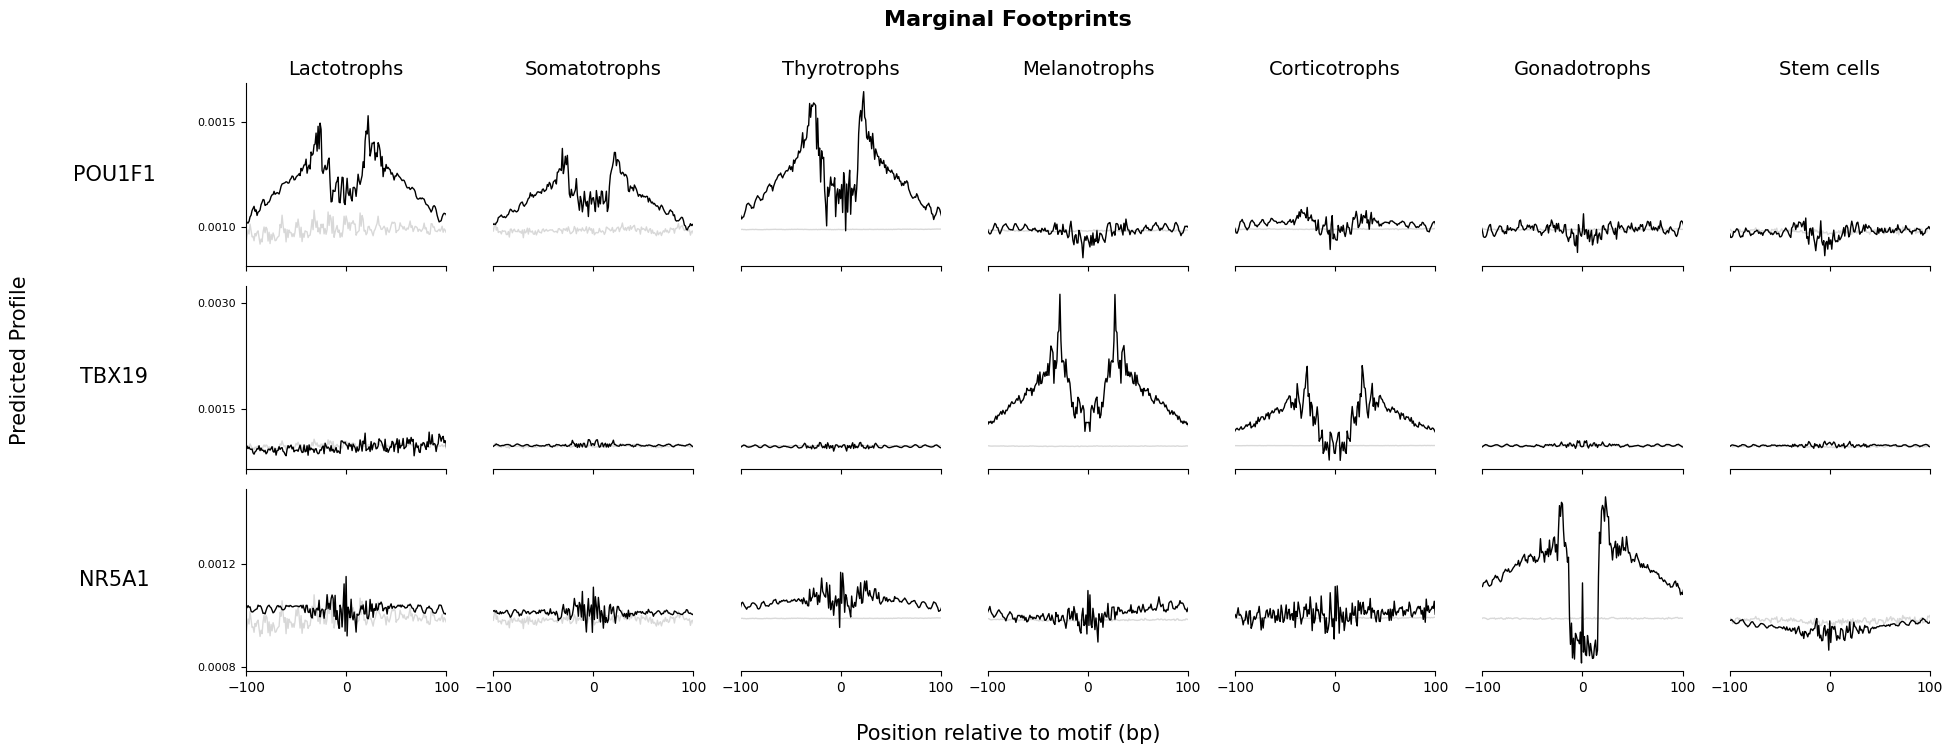

In [9]:
# TBX19 - POU1F1 - NR5A1

# Chosen cells to plot
cell_types = [
    'Lactotrophs',
    'Somatotrophs',
    'Thyrotrophs',
    'Melanotrophs',
    'Corticotrophs',
    'Gonadotrophs',
    'Stem_cells'
]

# Chosen TFs to plot
tf_ids = [
    'MA0784.1',
    'MA0804.1',
    'MA1540.1',
]

plot_footprint_grid(cell_types, tf_ids, file_paths, id_to_motif, 
                   save_path="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/footprints/MAIN_footprints.pdf")

In [ ]:
# GATA2 KO

cell_types = [
    'Gonadotrophs',
    'Gonadotrophs_Gata2_KO',
]

tf_ids = [
    'MA0036.1',
    'MA0036.2',
    'MA0036.3',
    'MA0036.4',
]

plot_footprint_grid(cell_types, tf_ids, file_paths, id_to_motif,
                        save_path="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/footprints/KO_GATA2_footprints.pdf")

In [12]:
# Paths of TFModisco Motifs found

file_paths_tfmodisco = {
    'Corticotrophs':        '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Corticotrophs/marginal_footprints/Corticotrophs_TFModisco_footprints.h5',
    'Lactotrophs':          '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Lactotrophs/marginal_footprints/Lactotrophs_TFModisco_footprints.h5',
    'Somatotrophs':         '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Somatotrophs/marginal_footprints/Somatotrophs_TFModisco_footprints.h5',
    'Thyrotrophs':          '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Thyrotrophs/marginal_footprints/Thyrotrophs_TFModisco_footprints.h5',
    'Gonadotrophs':         '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Gonadotrophs/marginal_footprints/Gonadotrophs_TFModisco_footprints.h5',
    'Melanotrophs':         '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Melanotrophs/marginal_footprints/Melanotrophs_TFModisco_footprints.h5',
    'Stem_cells':           '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Stem_cells/marginal_footprints/Stem_cells_TFModisco_footprints.h5',
    'Gonadotrophs_Gata2_KO':'/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Gonadotrophs_Gata2_KO/marginal_footprints/Gonadotrophs_Gata2_KO_TFModisco_footprints.h5',
    'Gonadotrophs_SF1_KO':  '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Gonadotrophs_SF1_KO/marginal_footprints/Gonadotrophs_SF1_KO_TFModisco_footprints.h5',
}

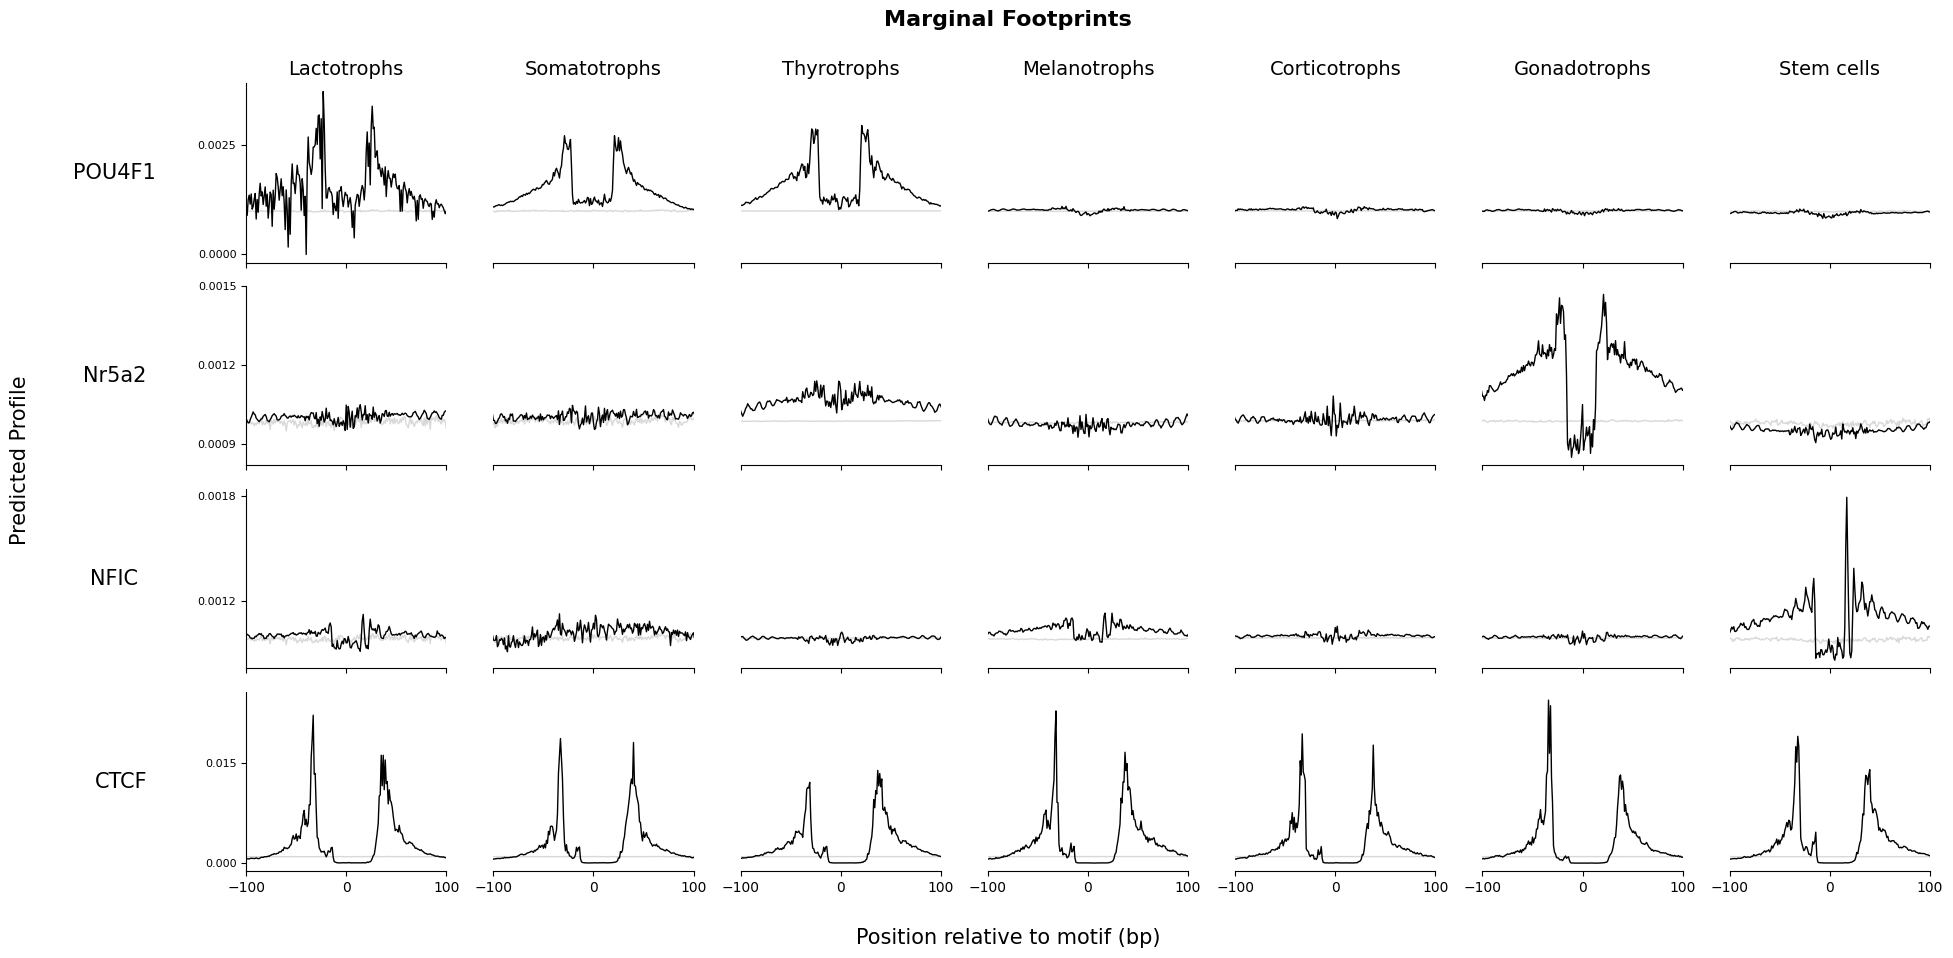

In [35]:
# TFModisco Results

cell_types = [
    'Lactotrophs',
    'Somatotrophs',
    'Thyrotrophs',
    'Melanotrophs',
    'Corticotrophs',
    'Gonadotrophs',
    'Stem_cells'
]

tf_ids = [
    'MA0790.1', #POU4F1 - correct 
    'MA0505.3', #NR5A2 (not MA0505.1 or MA0505.2)
    'MA0161.1', #NFIC - correct
    'MA1929.1', #CTCF (not MA0139.1, MA1930.1, or MA1939.2)
]

plot_footprint_grid(cell_types, tf_ids, file_paths_tfmodisco, id_to_motif)

Successfully saved plot to: /scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/footprints/NFIX_footprints.pdf


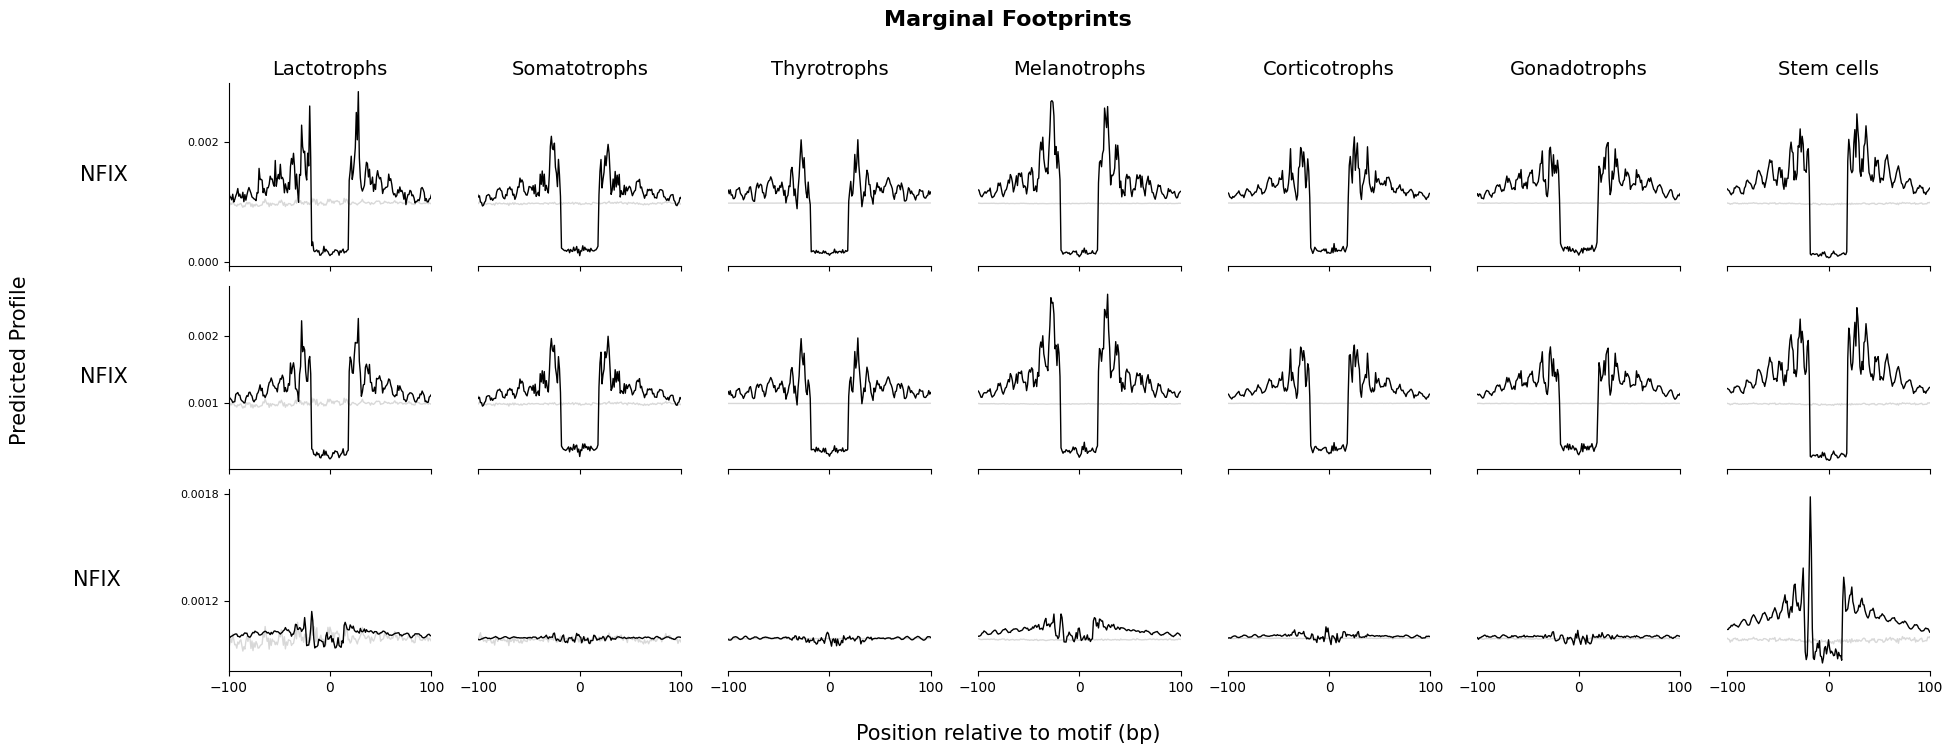

In [22]:
cell_types = [
    'Lactotrophs',
    'Somatotrophs',
    'Thyrotrophs',
    'Melanotrophs',
    'Corticotrophs',
    'Gonadotrophs',
    'Stem_cells'
]

tf_ids = [
    'MA1528.1', #NFIX (not MA0671.1)
    'MA1528.2', #NFIX (not MA0671.1)
    'MA0671.2', #NFIX (not MA0671.1)
    #'MA0161.1', #NFIC - correct
    #'MA1119.1', # SIX2
    #'MA0139.1', #CTCF
]

plot_footprint_grid(cell_types, tf_ids, file_paths, id_to_motif,
                   save_path="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/footprints/NFIX_footprints.pdf")

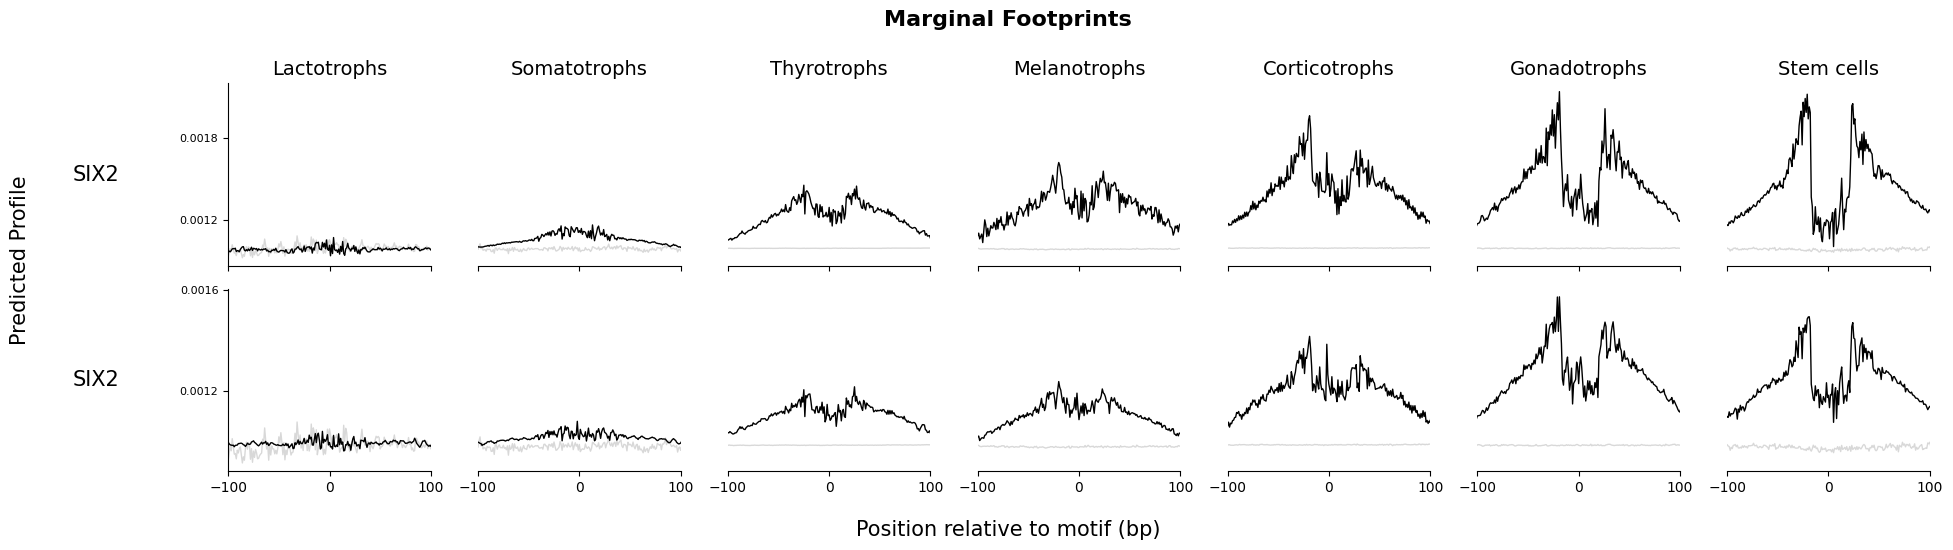

In [33]:
cell_types = [
    'Lactotrophs',
    'Somatotrophs',
    'Thyrotrophs',
    'Melanotrophs',
    'Corticotrophs',
    'Gonadotrophs',
    'Stem_cells'
]

tf_ids = [
    'MA1119.1', # SIX2
    'MA1119.2', # SIX2
]

plot_footprint_grid(cell_types, tf_ids, file_paths, id_to_motif)

## **Contribs_bw --> TFModisco**

### _Libraries_

In [54]:
# Load libraries
import h5py
import hdf5plugin
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import re
import glob 
from matplotlib import colors
import logomaker

import sys
#!{sys.executable} -m pip install lxml

### contribs.profile_scores.h5 - contribution score offset

In [39]:
# Contribution Profile Scores (h5)

Lacto_pc="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Lactotrophs/contribs_bw/Lactotrophs_contribs.profile_scores.h5"

with h5py.File(Lacto_pc, 'r') as file:
    # See top level
    print("Keys:", list(file.keys()))
    
    # Pick a group and see what's inside
    group_name = 'projected_shap'
    print(f"Inside {group_name}:", list(file[group_name].keys()))
    
    group_name2 = 'raw'
    print(f"Inside {group_name2}:", list(file[group_name2].keys()))

    group_name3 = 'shap'
    print(f"Inside {group_name3}:", list(file[group_name3].keys()))

Keys: ['projected_shap', 'raw', 'shap']
Inside projected_shap: ['seq']
Inside raw: ['seq']
Inside shap: ['seq']


In [40]:
# See what is further inside the keys

with h5py.File(Lacto_pc, 'r') as file:
    seq_data = file['projected_shap/seq']
    
    print(f"Shape: {seq_data.shape}")
    print(f"Datatype: {seq_data.dtype}")

Shape: (245876, 4, 2114)
Datatype: float16


**There are 245'876 genomic regions.**

**Each genomic region is represented with the 4 base pairs (A,C,T,G).**

**Each genomic region is 2114 base pairs long.**

In [44]:
# Check this number of regions matches the input regions provided

peaks_file = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/mm10/peaks/consensus_chromatin_landscape_modified.bed.gz"

peaks = pd.read_csv(peaks_file, 
                    sep='\t', header=None, compression='gzip')

print(f"Number of regions in BED: {len(peaks)}")

Number of regions in BED: 245876


**The contribs outputs from contribs_bw get fed into the tf_modisco command.**

**This command then generates a list of top contribution sequences, names them seqlets and says how many there are.**

In [49]:
# Generate a dictionary of patterns within the tfmodisco results and their associated TF name

named_results = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Lactotrophs/tf_modisco/Lactotrophs_modisco_results_named.csv"

name_map_df = pd.read_csv(named_results)
name_dict = dict(zip(name_map_df['pattern'], name_map_df['motif0']))

#name_dict

In [50]:
modisco_h5 = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Lactotrophs/tf_modisco/modisco_results.h5"
contribs_h5 = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Lactotrophs/contribs_bw/Lactotrophs_contribs.profile_scores.h5"

with h5py.File(modisco_h5, 'r') as m_file, \
     h5py.File(contribs_h5, 'r') as c_file:
        
        # Extract the contribution score dataset
        contrib_ds = c_file['projected_shap/seq']
        # Select for positive patterns only 
        pos_patterns = m_file['pos_patterns']
        
        for p_key in pos_patterns.keys():
            # pattern_0, pattern_1, etc.
            pattern_grp = pos_patterns[p_key]
                
            lookup_key = f"pos_patterns.{p_key}"
            readable_name = name_dict.get(lookup_key, p_key)
            
            # Get seqlet indices and coordinates
            seqlets = pattern_grp['seqlets']
            indices = seqlets['example_idx'][:].astype(int)
            starts = seqlets['start'][:].astype(int)
            ends = seqlets['end'][:].astype(int)
            
            pattern_scores = []
            
            # Pull scores for every instance of this motif
            for idx, s, e in zip(indices, starts, ends):
                # Pull the specific sequence window (shape: 4, 2114)
                region_data = contrib_ds[idx] 

In [51]:

with h5py.File(modisco_h5, 'r') as m_file, h5py.File(contribs_h5, 'r') as c_file:
    
    # Access the groups
    pos_patterns = m_file['pos_patterns']
    contrib_ds = c_file['projected_shap/seq']
    
    # Pick the first pattern (first key for an example
    p_key = list(pos_patterns.keys())[1]
    pattern_grp = pos_patterns[p_key]
    
    # Get the seqlet's coordinates from that pattern
    seqlets = pattern_grp['seqlets']
    idx = int(seqlets['example_idx'][1])
    s = int(seqlets['start'][1])
    e = int(seqlets['end'][1])

Visualizing Pattern: pattern_1
Region Index: 16438 | Coordinates: 286:316


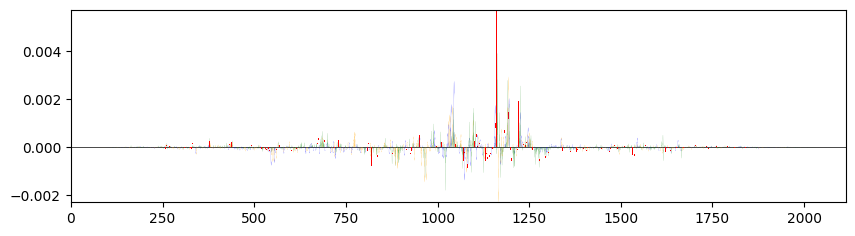

In [59]:
# Look at the total 2114 region contribution scores for the first pattern selected 

motif_to_plot = region_data.T
    
print(f"Visualizing Pattern: {p_key}")
print(f"Region Index: {idx} | Coordinates: {s}:{e}")
    
df = pd.DataFrame(motif_to_plot, columns=['A', 'C', 'G', 'T'])
logomaker.Logo(df, color_scheme='classic')
plt.show()

**Region Index is the region number within the coordinates file.**

**The Coordinates is where the tfmodisco output has deemed the 'start' and 'end' sites of the particular motif**

Visualizing Pattern: pattern_1
Region Index: 16438 | Coordinates: 286:316


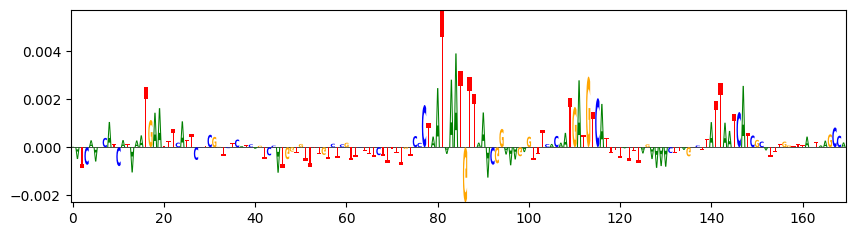

In [58]:
# Zoom in for better clarity

zoomed_data = region_data[:, 1080:1250]
motif_to_plot = zoomed_data.T
    
print(f"Visualizing Pattern: {p_key}")
print(f"Region Index: {idx} | Coordinates: {s}:{e}")
    
df = pd.DataFrame(motif_to_plot, columns=['A', 'C', 'G', 'T'])
logomaker.Logo(df, color_scheme='classic')
plt.show()

**Obviously, the region of highest contribution is not between 286-316 when looking at the entire 2114bp window**

In [60]:
# Determine the position of highest importance within the sequence region

importance_track = np.sum(region_data, axis=0)
peak_center = np.argmax(importance_track)
print(f"The highest contribution in this region is at position: {peak_center}")

The highest contribution in this region is at position: 1161


In [61]:
# Calculate the total importance across the whole 2114 bp

importance_track = np.sum(region_data, axis=0)
actual_peak_index = np.argmax(importance_track)

print(f"The region of highest contribution is around: {actual_peak_index}")
print(f"TFModisco says the seqlet starts at: {s}")

# Calculate offset between actual peak and seqlet center
offset = actual_peak_index - (s + (e-s)//2)
print(f"Offset for positive pattern_0: {offset}")

The region of highest contribution is around: 1161
TFModisco says the seqlet starts at: 286
Offset for positive pattern_0: 860


<Figure size 1000x200 with 0 Axes>

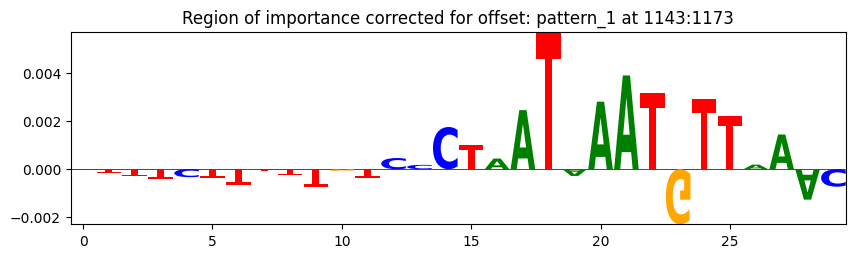

In [65]:
# Visualise contribution sequence score correcting for the estimated offset

# Assuming a 400bp window from original 2114bp region
# crop_start = ( 2114 / 2 ) - 200 
crop_start = 857

# Re-zoom into the data using the offset
true_s = s + crop_start
true_e = e + crop_start

# Extract the ACTUAL spike area
motif_data = region_data[:, true_s:true_e].T
df = pd.DataFrame(motif_data, columns=['A', 'C', 'G', 'T'])

# Plot - this will now show the actual letters of the spike!
plt.figure(figsize=(10, 2))
logomaker.Logo(df, color_scheme='classic')
plt.title(f"Region of importance corrected for offset: {p_key} at {true_s}:{true_e}")
plt.show()

**TFModisco cuts the region window to a 400bp window.**

**This means their 'start' and 'end' values are relative to the 400bp window, NOT the 2114bp region**

### modisco_results.h5 - merge all identified motifs 

**The TFModisco command generated a file called grouping_X_X_modisco_results.h5 file per cell type.**

**These motifs are what the function identified as the top motifs extracted from the specific groupings.**

**To be able to visualise these in the marginal footprinting, they need to be merged together and run in the marginal footprinting command as one, regardless of cell type.**

In [69]:
Lacto_modisco = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Lactotrophs/tf_modisco/grouping_6_up_modisco_results_named.csv"
Lacto_modisco

'/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/Lactotrophs/tf_modisco/grouping_6_up_modisco_results_named.csv'

**Within this file: match0 = MA ID that is predicted to be the TF associated with that sequence presence**

In [70]:
df = pd.read_csv(Lacto_modisco)
print(df.head())

                  pattern  num_seqlets    match0      motif0     qval0  \
0  pos_patterns.pattern_0         4846  MA0790.1      POU4F1  0.142750   
1  pos_patterns.pattern_1         4220  MA0835.3       BATF3  0.000318   
2  pos_patterns.pattern_2         3272  MA0790.1      POU4F1  0.005070   
3  pos_patterns.pattern_3         3096  MA1467.2       Atoh1  0.000047   
4  pos_patterns.pattern_4         2708  MA0119.1  NFIC::TLX1  0.020852   

     match1   motif1     qval1    match2   motif2     qval2  
0  MA0791.1   POU4F3  0.142750  MA0683.1   POU4F2  0.176192  
1  MA1988.2     Atf3  0.000318  MA2486.1     Fosb  0.000318  
2  MA0791.1   POU4F3  0.005070  MA0791.2   POU4F3  0.005070  
3  MA1642.1  NEUROG2  0.000155  MA0668.2  Neurod2  0.000218  
4  MA1528.2     NFIX  0.020852  MA1528.1     NFIX  0.023387  


In [ ]:
# NO NEED TO RUN AGAIN - ALREADY DONE

# Extract match0 results and generate a .tsv file per cell type of JUST the MA IDs identified
base = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs"

files = [
    "Corticotrophs/tf_modisco/grouping_4_down_modisco_results_named.csv",
    "Melanotrophs/tf_modisco/grouping_4_up_modisco_results_named.csv",
    "Gonadotrophs/tf_modisco/grouping_2_up_modisco_results_named.csv",
    "Somatotrophs/tf_modisco/grouping_7_up_modisco_results_named.csv",
    "Gonadotrophs_Gata2_KO/tf_modisco/grouping_2_up_modisco_results_named.csv",
    "Stem_cells/tf_modisco/grouping_1_up_modisco_results_named.csv",
    "Gonadotrophs_SF1_KO/tf_modisco/grouping_2_up_modisco_results_named.csv",
    "Thyrotrophs/tf_modisco/grouping_8_up_modisco_results_named.csv",
    "Lactotrophs/tf_modisco/grouping_6_up_modisco_results_named.csv",
]

for rel_path in files:
    full_path = os.path.join(base, rel_path)
    
    # Extract grouping_X_X from filename, e.g. grouping_6_up
    fname = os.path.basename(full_path)
    match = re.search(r'(grouping_\d+_\w+)', fname)
    grouping_tag = match.group(1) if match else "grouping_unknown"
    
    # Output file goes in the same tf_modisco directory
    out_dir = os.path.dirname(full_path)
    out_file = os.path.join(out_dir, f"{grouping_tag}_TFModisco_list.tsv")
    
    # Read and extract
    df = pd.read_csv(full_path)
    match0_series = df[['match0']].drop_duplicates().reset_index(drop=True)
    
    match0_series.to_csv(out_file, sep='\t', index=False, header=False)
    print(f"Saved: {out_file}")

# Extract the files generated above and merge into one 

base = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs"

## Collect all individual TFModisco list files
tsv_files = glob.glob(os.path.join(base, "*/tf_modisco/*_TFModisco_list.tsv"))

all_match0 = []
for f in tsv_files:
    series = pd.read_csv(f, header=None, sep='\t').squeeze()
    all_match0.append(series)

# Merge, deduplicate, and save
merged = pd.concat(all_match0).drop_duplicates().reset_index(drop=True)

merged_out = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/grouping_motifs_from_TFmodisco.tsv"
merged.to_csv(merged_out, sep='\t', index=False, header=False)
print(f"Merged {len(tsv_files)} files → {merged_out}  ({len(merged)} unique motifs)")

In [ ]:
# NO NEED TO RUN AGAIN - ALREADY DONE

# Associate the correct sequence pattern with each MA id within the file generated above

# Load the MA IDs from the TFModisco results
modisco_ids = pd.read_csv("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/grouping_motifs_from_TFmodisco.tsv", header=None, sep='\t').squeeze().tolist()

# Load motif_sequences.tsv (no header, two columns: MA ID and sequence)
motif_seq = pd.read_csv("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences.tsv", header=None, sep='\t', names=['ma_id', 'sequence'])

# Filter for matching MA IDs
filtered = motif_seq[motif_seq['ma_id'].isin(modisco_ids)]

# Save
out = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/TFModisco_grouping_motifs.tsv"
filtered.to_csv(out, sep='\t', index=False, header=False)
print(f"Matched {len(filtered)} / {len(modisco_ids)} motifs")

### Bubble Plot + Median Distribution - Top Motifs from TFModisco

How to tackle this:
    
- TF frequencies: found in tf_modisco/modisco_results.h5
- Contribution scores: found in contribs_bw/*.profile_scores.h5 (specifically the projected_shap key)

#### Functions

In [74]:
# Extract the TF Motifs identified per cell type, their frequency, and respective median contribution score
# This does not correct for the offset - refer to next code 

cell_types = ["Corticotrophs", "Gonadotrophs", "Lactotrophs", "Melanotrophs", "Somatotrophs", "Stem_cells", "Thyrotrophs"]
base_dir = Path("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs")

def get_all_celltype_contribs(cell_list):
    all_results = []
    all_means_dict = {}
    
    # Standard offset for 2114bp total length and 400bp TFModisco window
    # (2114 - 400) // 2 = 857
    OFFSET = 857
        
    for cell in cell_list:
        print(f"Processing {cell}")
        
        # File paths
        modisco_h5 = base_dir / cell / "tf_modisco" / "modisco_results.h5"
        named_results = base_dir / cell / "tf_modisco" / f"{cell}_modisco_results_named.csv"
        contribs_h5 = base_dir / cell / "contribs_bw" / f"{cell}_contribs.profile_scores.h5"

        # Check if files exist before opening
        if not (modisco_h5.exists() and contribs_h5.exists() and named_results.exists()):
            print(f"Skipping {cell}: Missing files.")
            continue

        # Load naming map
        name_map_df = pd.read_csv(named_results)
        name_dict = dict(zip(name_map_df['pattern'], name_map_df['motif0']))

        with h5py.File(modisco_h5, 'r') as m_file, \
             h5py.File(contribs_h5, 'r') as c_file:
            
            contrib_ds = c_file['projected_shap/seq']
            pos_patterns = m_file['pos_patterns']
            
            for p_key in pos_patterns.keys():
                pattern_grp = pos_patterns[p_key]
                
                # Try lookup with and without prefix
                readable_name = name_dict.get(p_key, name_dict.get(f"pos_patterns.{p_key}", p_key))
                
                seqlets = pattern_grp['seqlets']
                indices = seqlets['example_idx'][:].astype(int)
                starts = seqlets['start'][:].astype(int)
                ends = seqlets['end'][:].astype(int)
                
                pattern_scores = []
                for idx, s, e in zip(indices, starts, ends):
                    
                    # Load the (4, 2114) region
                    region_data = contrib_ds[idx].astype('float32')
                    # Sum across nucleotides (axis 0) to get 1D importance track
                    importance_track = np.sum(region_data, axis=0)
                    # Apply the fixed 857 offset
                    val = np.mean(importance_track[s + OFFSET : e + OFFSET])
                    pattern_scores.append(val)
                
                all_means_dict[(cell, readable_name)] = pattern_scores
                
                all_results.append({
                    'cell_type': cell,
                    'tf_name': readable_name,
                    'frequency': len(indices),
                    'median_score': np.median(pattern_scores)
                })
                

    return pd.DataFrame(all_results), all_means_dict

In [75]:
# Same function but with added factor: Groupings

cell_types = ["Corticotrophs", "Gonadotrophs", "Lactotrophs", "Melanotrophs", "Somatotrophs", "Stem_cells", "Thyrotrophs"]
cell_group_map = {
    "Corticotrophs": "grouping_4_down",
    "Gonadotrophs": "grouping_2_up",
    "Lactotrophs": "grouping_6_up",
    "Melanotrophs": "grouping_4_up",
    "Somatotrophs": "grouping_7_up",
    "Stem_cells": "grouping_1_up",
    "Thyrotrophs": "grouping_8_up"
}
base_dir = Path("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs")

def get_all_celltype_contribs_groups(group_map):
    all_results = []
    all_means_dict = {}
    
    # Standard offset for 2114bp total length and 400bp TFModisco window
    # (2114 - 400) // 2 = 857
    OFFSET = 857 
    
    for cell, group in group_map.items():
        print(f"Processing {cell} ({group})")
        
        modisco_h5 = base_dir / cell / "tf_modisco" / f"{group}_modisco_results.h5"
        named_results = base_dir / cell / "tf_modisco" / f"{group}_modisco_results_named.csv"
        contribs_h5 = base_dir / cell / "contribs_bw" / f"{cell}_{group}_contribs.profile_scores.h5"

        if not (modisco_h5.exists() and contribs_h5.exists() and named_results.exists()):
            continue

        name_map_df = pd.read_csv(named_results)
        name_dict = dict(zip(name_map_df['pattern'], name_map_df['motif0']))

        with h5py.File(modisco_h5, 'r') as m_file, h5py.File(contribs_h5, 'r') as c_file:
            contrib_ds = c_file['projected_shap/seq']
            pos_patterns = m_file['pos_patterns']
            
            for p_key in pos_patterns.keys():
                pattern_grp = pos_patterns[p_key]
                readable_name = name_dict.get(p_key, name_dict.get(f"pos_patterns.{p_key}", p_key))
                
                seqlets = pattern_grp['seqlets']
                indices = seqlets['example_idx'][:].astype(int)
                starts = seqlets['start'][:].astype(int)
                ends = seqlets['end'][:].astype(int)
                
                pattern_scores = []
                for idx, s, e in zip(indices, starts, ends):
                    
                    # Load the (4, 2114) region
                    region_data = contrib_ds[idx].astype('float32')
                    # Sum across nucleotides (axis 0) to get 1D importance track
                    importance_track = np.sum(region_data, axis=0)
                    # Apply the fixed 857 offset
                    val = np.mean(importance_track[s + OFFSET : e + OFFSET])
                    pattern_scores.append(val)
                
                all_means_dict[(cell, readable_name)] = pattern_scores
                
                all_results.append({
                    'cell_type': cell,
                    'tf_name': readable_name,
                    'frequency': len(indices),
                    'median_score': np.median(pattern_scores)
                })

    return pd.DataFrame(all_results), all_means_dict


In [78]:
# Function for plotting median distribution of a specific TF Motif in a cell type

def plot_tf_median_distribution(cell, tf, scores_dict):
    data = scores_dict.get((cell, tf))
    
    if data:
        plt.figure(figsize=(9, 6))
        
        plt.hist(data, bins=50, color='#3498db', 
                 edgecolor='white', alpha=0.8, density=False)
        
        median_val = np.median(data)
        plt.axvline(median_val, color='red', linestyle='solid', linewidth=1.5, 
                    label=f'Median: {median_val:.8f}')
        
        plt.title(f"Motif Contribution Score Distribution\n{tf} - {cell}", fontsize=14, pad=15)
        plt.xlabel("Motif Mean Contribution Score", fontsize=12)
        plt.ylabel("Number of Seqlets", fontsize=12)
        plt.grid(axis='y', alpha=0.2)
        plt.legend()
        plt.tight_layout()

        plt.savefig(f"/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/motif_means/{cell}_{tf}.png")

        plt.show()
    else:
        print(f"Error: No data found for {tf} in {cell}.")

In [80]:
# Function for plotting median contributions of one TF across all cell types

def plot_tf_median_distribution_allcells(cell_list, tf, scores_dict):
    plt.figure(figsize=(10, 6))
    
    colors = [
        '#3498db', # Blue
        '#e74c3c', # Red
        '#2ecc71', # Green
        '#f1c40f', # Yellow
        '#9b59b6', # Purple
        '#e67e22', # Orange
        '#1abc9c', # Teal
        '#34495e'  # Dark Grey/Navy
    ]
    found_any = False
    
    # Set your bin edges once so all cell types use the same "buckets"
    # Range is 0 to 0.0090 as per your plt.xlim
    bins = np.linspace(0, 0.0090, 100) 

    for i, cell in enumerate(cell_list):
        data = scores_dict.get((cell, tf))
        
        if data is not None and len(data) > 0:
            found_any = True
            
            # Calculate the histogram counts
            counts, bin_edges = np.histogram(data, bins=bins)
            
            # Calculate the center of each bin for plotting the points
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Plot as a step-line or a simple line
            color = colors[i % len(colors)]
            plt.plot(bin_centers, counts, color=color, linewidth=2, 
                     label=f"{cell} (Med: {np.median(data):.8f})")
    
    if found_any:
        plt.title(f"Motif Contribution Score Distribution: {tf}", fontsize=14, pad=15)
        plt.xlabel("Motif Mean Contribution Score", fontsize=12)
        plt.ylabel("Number of Seqlets", fontsize=12) # Back to counts
        plt.xlim(0, 0.009)
        plt.grid(axis='both', alpha=0.2)
        plt.legend()
        plt.tight_layout()

        cell_tag = "_".join(cell_list[:3])
        save_path = f"/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/motif_means/{tf}_{cell_tag}.png"
        
        plt.savefig(save_path, dpi=300)
        print(f"Saved comparison plot to: {save_path}")
        plt.show()
    else:
        print(f"Error: No data found for {tf} in the requested cells.")

#### Bubble Plot

In [ ]:
# Run the general initial function
master_df, total_means_distribution = get_all_celltype_contribs(cell_types)
print(master_df.head())

# Run the function for reduced peaks by GROUPINGS 
groups_df, groups_means_distribution = get_all_celltype_contribs_groups(cell_group_map)
print(groups_df.head())

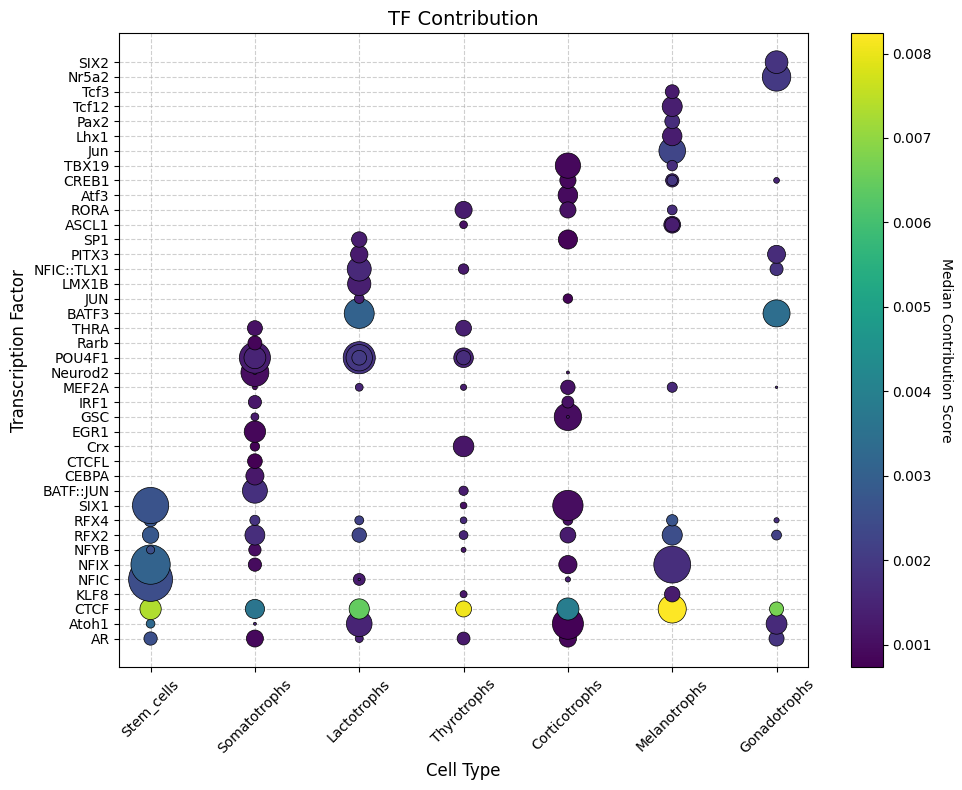

In [77]:
cell_order = ["Stem_cells", "Somatotrophs", "Lactotrophs", "Thyrotrophs", "Corticotrophs", "Melanotrophs", "Gonadotrophs"]

# Filter for top 20 TFs
top_tfs = groups_df.groupby('tf_name')['frequency'].sum().nlargest(40).index
plot_df = groups_df[groups_df['tf_name'].isin(top_tfs)].copy()

plot_df['cell_type'] = pd.Categorical(plot_df['cell_type'], categories=cell_order, ordered=True)
plot_df = plot_df.sort_values(['cell_type', 'tf_name'])

# Setup the figure
plt.figure(figsize=(10, 8))
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)

# Scale the bubble sizes
max_bubble_size = 1000 
size_scale = plot_df['frequency'] / plot_df['frequency'].max() * max_bubble_size

# Create the scatter
# c = contribution, s = size
scatter = plt.scatter(
    x=plot_df['cell_type'], 
    y=plot_df['tf_name'], 
    s=size_scale, 
    c=plot_df['median_score'], 
    cmap='viridis', 
    edgecolors='black', 
    linewidths=0.5,
    alpha=1,
    zorder=3
)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Median Contribution Score', rotation=270, labelpad=15)

# Formatting
plt.title('TF Contribution', fontsize=14)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Transcription Factor', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/Contribs_bubble_plot_groupings.png', dpi=300, bbox_inches='tight')
plt.show()

#### Median Distribution

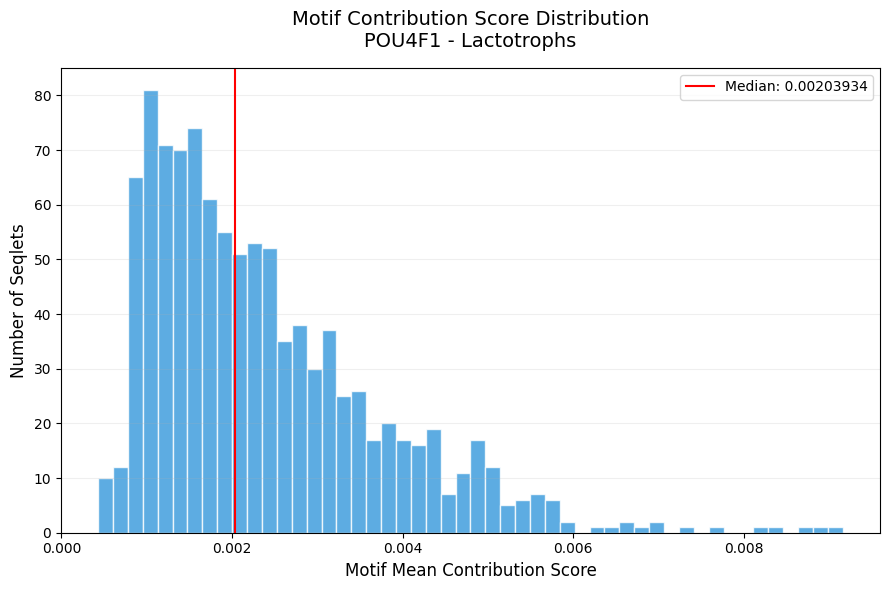

In [81]:
# Plot individual means distribution of one TF in one cell type
plot_tf_median_distribution("Lactotrophs", "POU4F1", groups_means_distribution)

Saved comparison plot to: /scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/motif_means/CTCF_Gonadotrophs_Melanotrophs_Lactotrophs.png


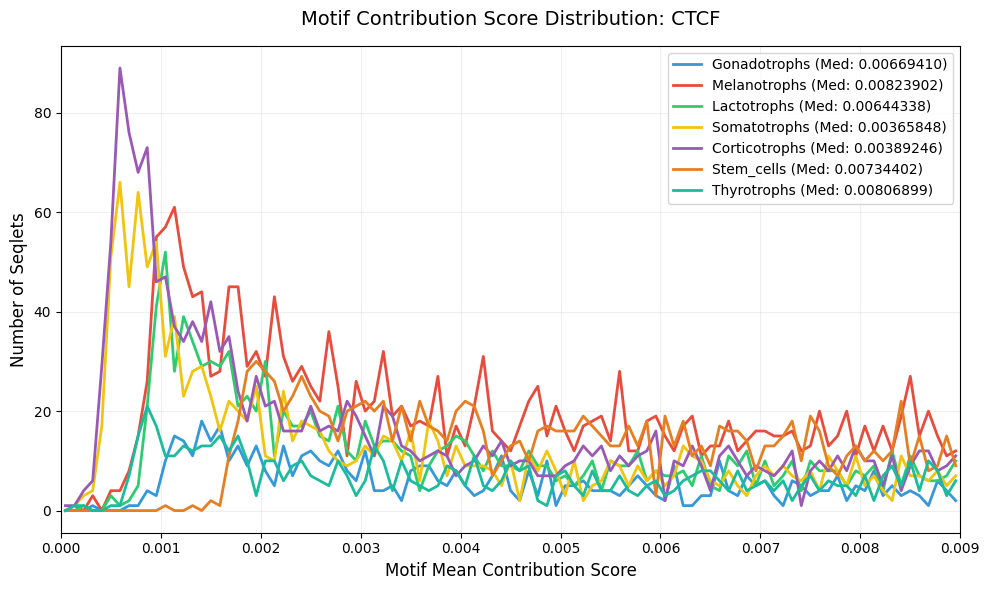

In [82]:
# Plot one TF across all cell types
# This connects the middle of each "bin" - it is not a continuous line plot 

cells_to_compare = ["Gonadotrophs", "Melanotrophs", "Lactotrophs", 
                    "Somatotrophs", "Corticotrophs", "Stem_cells", "Thyrotrophs"
                   ]

plot_tf_median_distribution_allcells(cells_to_compare, "CTCF", groups_means_distribution)